In [ ]:
# Importing DATA
# This cell serves as a marker for the data import section.

In [ ]:
from google.colab import files
uploaded = files.upload() # Upload files from local system

In [ ]:
import pandas as pd
games = pd.read_csv("games.csv") # Load games data
sales = pd.read_csv("vgsales.csv") # Load sales data

In [ ]:
games_copy = games.copy() # Create copies for cleaning
sales_copy = sales.copy() # Create copies for cleaning

Table information

In [ ]:
games.info() # Display games DataFrame summary
sales.info() # Display sales DataFrame summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1512 non-null   int64  
 1   Title              1512 non-null   object 
 2   Release Date       1512 non-null   object 
 3   Team               1511 non-null   object 
 4   Rating             1499 non-null   float64
 5   Times Listed       1512 non-null   object 
 6   Number of Reviews  1512 non-null   object 
 7   Genres             1512 non-null   object 
 8   Summary            1511 non-null   object 
 9   Reviews            1512 non-null   object 
 10  Plays              1512 non-null   object 
 11  Playing            1512 non-null   object 
 12  Backlogs           1512 non-null   object 
 13  Wishlist           1512 non-null   object 
dtypes: float64(1), int64(1), object(12)
memory usage: 165.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entr

In [ ]:
games.dtypes # Display games DataFrame dtypes
sales.dtypes # Display sales DataFrame dtypes

,0
Rank,int64
Name,object
Platform,object
Year,float64
Genre,object
Publisher,object
NA_Sales,float64
EU_Sales,float64
JP_Sales,float64
Other_Sales,float64


In [ ]:
## text cleaning removing spaces

text_cols = ['Title', 'Team', 'Genres'] # Define text columns to clean

for col in text_cols: # Iterate through text columns
    games_copy[col] = (
        games_copy[col]
        .astype(str)
        .str.strip() # Strip whitespace
        .str.upper() # Convert to uppercase
    )

games_copy # Display modified DataFrame

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,0,ELDEN RING,"Feb 25, 2022","['BANDAI NAMCO ENTERTAINMENT', 'FROMSOFTWARE']",4.5,3.9K,3.9K,"['ADVENTURE', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K
1,1,HADES,"Dec 10, 2019",['SUPERGIANT GAMES'],4.3,2.9K,2.9K,"['ADVENTURE', 'BRAWLER', 'INDIE', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K
2,2,THE LEGEND OF ZELDA: BREATH OF THE WILD,"Mar 03, 2017","['NINTENDO', 'NINTENDO EPD PRODUCTION GROUP NO...",4.4,4.3K,4.3K,"['ADVENTURE', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K
3,3,UNDERTALE,"Sep 15, 2015","['TOBYFOX', '8-4']",4.2,3.5K,3.5K,"['ADVENTURE', 'INDIE', 'RPG', 'TURN BASED STRA...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K
4,4,HOLLOW KNIGHT,"Feb 24, 2017",['TEAM CHERRY'],4.4,3K,3K,"['ADVENTURE', 'INDIE', 'PLATFORM']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507,1507,BACK TO THE FUTURE: THE GAME,"Dec 22, 2010",['TELLTALE GAMES'],3.2,94,94,"['ADVENTURE', 'POINT-AND-CLICK']",Back to the Future: The Game is one of Telltal...,['Very enjoyable game. The story adds onto the...,763,5,223,67
1508,1508,TEAM SONIC RACING,"May 21, 2019","['SUMO DIGITAL', 'SEGA']",2.9,264,264,"['ARCADE', 'RACING']",Team Sonic Racing combines the best elements o...,"['jogo morto mas bom', 'not my cup of tea', ""C...",1.5K,49,413,107
1509,1509,DRAGON'S DOGMA,"May 22, 2012",['CAPCOM'],3.7,210,210,"['BRAWLER', 'RPG']","Set in a huge open world, Dragon’s Dogma: Dark...","['Underrated.', 'A grandes rasgos, es como un ...",1.1K,45,487,206
1510,1510,BALDUR'S GATE 3,"Oct 06, 2020",['LARIAN STUDIOS'],4.1,165,165,"['ADVENTURE', 'RPG', 'STRATEGY', 'TACTICAL', '...","An ancient evil has returned to Baldur's Gate,...",['Bu türe bu oyunla girmeye çalışmak hataydı s...,269,79,388,602


In [ ]:
# Fill nulls in object columns of games_copy with 'unknown'
for col in games_copy.select_dtypes(include='object').columns:
    if games_copy[col].isnull().any():
        games_copy[col] = games_copy[col].fillna('unknown')

# Fill nulls in object columns of sales_copy with 'unknown'
for col in sales_copy.select_dtypes(include='object').columns:
    if sales_copy[col].isnull().any():
        sales_copy[col] = sales_copy[col].fillna('unknown')

print("Null values in games_copy after filling:") # Report remaining nulls
display(games_copy.isnull().sum()[games_copy.isnull().sum() > 0])

print("\nNull values in sales_copy after filling:") # Report remaining nulls
display(sales_copy.isnull().sum()[sales_copy.isnull().sum() > 0])

Null values in games_copy after filling:


,0
Rating,13



Null values in sales_copy after filling:


,0
Year,271


In [ ]:
# Function to convert 'K' (thousands) to numerical values
def convert_k(value):
    if isinstance(value, str):
        value = value.strip()
        if 'K' in value: # If 'K' present, remove and multiply by 1000
            return round(float(value.replace('K', '')), 2)
        else: # No 'K', divide by 1000 (already large num)
            return round(float(value) / 1000, 2)
    elif isinstance(value, (int, float)): # Already number, just round
        return round(float(value), 2)
    return value

num_cols_games = ['Plays', 'Wishlist', 'Playing', 'Backlogs', 'Times Listed', 'Number of Reviews'] # Columns for 'K' conversion

for col in num_cols_games: # Apply conversion to specified columns
    games_copy[col] = games[col].apply(convert_k)

games_copy # Display modified DataFrame

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,0,ELDEN RING,"Feb 25, 2022","['BANDAI NAMCO ENTERTAINMENT', 'FROMSOFTWARE']",4.5,3.90,3.90,"['ADVENTURE', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17.00,3.80,4.60,4.80
1,1,HADES,"Dec 10, 2019",['SUPERGIANT GAMES'],4.3,2.90,2.90,"['ADVENTURE', 'BRAWLER', 'INDIE', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21.00,3.20,6.30,3.60
2,2,THE LEGEND OF ZELDA: BREATH OF THE WILD,"Mar 03, 2017","['NINTENDO', 'NINTENDO EPD PRODUCTION GROUP NO...",4.4,4.30,4.30,"['ADVENTURE', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30.00,2.50,5.00,2.60
3,3,UNDERTALE,"Sep 15, 2015","['TOBYFOX', '8-4']",4.2,3.50,3.50,"['ADVENTURE', 'INDIE', 'RPG', 'TURN BASED STRA...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28.00,0.68,4.90,1.80
4,4,HOLLOW KNIGHT,"Feb 24, 2017",['TEAM CHERRY'],4.4,3.00,3.00,"['ADVENTURE', 'INDIE', 'PLATFORM']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21.00,2.40,8.30,2.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507,1507,BACK TO THE FUTURE: THE GAME,"Dec 22, 2010",['TELLTALE GAMES'],3.2,0.09,0.09,"['ADVENTURE', 'POINT-AND-CLICK']",Back to the Future: The Game is one of Telltal...,['Very enjoyable game. The story adds onto the...,0.76,0.01,0.22,0.07
1508,1508,TEAM SONIC RACING,"May 21, 2019","['SUMO DIGITAL', 'SEGA']",2.9,0.26,0.26,"['ARCADE', 'RACING']",Team Sonic Racing combines the best elements o...,"['jogo morto mas bom', 'not my cup of tea', ""C...",1.50,0.05,0.41,0.11
1509,1509,DRAGON'S DOGMA,"May 22, 2012",['CAPCOM'],3.7,0.21,0.21,"['BRAWLER', 'RPG']","Set in a huge open world, Dragon’s Dogma: Dark...","['Underrated.', 'A grandes rasgos, es como un ...",1.10,0.04,0.49,0.21
1510,1510,BALDUR'S GATE 3,"Oct 06, 2020",['LARIAN STUDIOS'],4.1,0.17,0.17,"['ADVENTURE', 'RPG', 'STRATEGY', 'TACTICAL', '...","An ancient evil has returned to Baldur's Gate,...",['Bu türe bu oyunla girmeye çalışmak hataydı s...,0.27,0.08,0.39,0.60


In [ ]:
print(games_copy['Rating'].dtype) # Print Rating dtype
print(games_copy['Rating'].unique()) # Print unique Rating values
display(games_copy['Rating'].describe()) # Display Rating statistics

float64
[4.5 4.3 4.4 4.2 3.  3.7 4.1 3.8 3.3 4.6 2.6 3.9 4.  2.7 3.6 3.5 3.2 2.8
 2.1 3.4 3.1 2.9 2.5 1.9 2.4 2.3 nan 1.2 2.2 1.6 1.5 4.8 2.  1.4 0.7 1.8]


,Rating
count,1499.000000
mean,3.719346
std,0.532608
min,0.700000
25%,3.400000
50%,3.800000
75%,4.100000
max,4.800000


In [ ]:
null_ratings = games_copy[games_copy['Rating'].isnull()] # Find rows with null 'Rating'
print(f"Number of empty rows in 'Rating' column: {len(null_ratings)}") # Print count of nulls
print("Rows with empty 'Rating':")
display(null_ratings) # Display rows with null 'Rating'

Number of empty rows in 'Rating' column: 13
Rows with empty 'Rating':


,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
587,587,FINAL FANTASY XVI,"Jun 22, 2023","['SQUARE ENIX', 'SQUARE ENIX CREATIVE BUSINESS...",NaN,0.42,0.42,['RPG'],Final Fantasy XVI is an upcoming action role-p...,[],0.04,0.01,0.73,2.40
649,649,DEATH STRANDING 2,releases on TBD,['KOJIMA PRODUCTIONS'],NaN,0.10,0.10,"['ADVENTURE', 'SHOOTER']",unknown,[],0.00,0.00,0.21,0.64
713,713,FINAL FANTASY VII REBIRTH,"Dec 31, 2023",['SQUARE ENIX'],NaN,0.19,0.19,[],This next standalone chapter in the FINAL FANT...,[],0.02,0.00,0.35,1.10
719,719,LIES OF P,"Aug 01, 2023","['NEOWIZ', 'ROUND8 STUDIO']",NaN,0.17,0.17,['RPG'],"Inspired by the familiar story of Pinocchio, L...",[],0.01,0.00,0.26,0.94
726,726,JUDAS,"Mar 31, 2025",['GHOST STORY GAMES'],NaN,0.09,0.09,"['ADVENTURE', 'SHOOTER']",A disintegrating starship. A desperate escape ...,[],0.00,0.00,0.09,0.44
746,746,LIKE A DRAGON GAIDEN: THE MAN WHO ERASED HIS NAME,"Dec 31, 2023","['RYŪ GA GOTOKU STUDIOS', 'SEGA']",NaN,0.12,0.12,"['ADVENTURE', 'BRAWLER', 'RPG']",This game covers Kiryu's story between Yakuza ...,[],0.00,0.00,0.14,0.59
972,972,THE LEGEND OF ZELDA: TEARS OF THE KINGDOM,"May 12, 2023","['NINTENDO', 'NINTENDO EPD PRODUCTION GROUP NO...",NaN,0.58,0.58,"['ADVENTURE', 'RPG']",The Legend of Zelda: Tears of the Kingdom is t...,[],0.07,0.01,1.60,5.40
1130,1130,STAR WARS JEDI: SURVIVOR,"Apr 28, 2023","['RESPAWN ENTERTAINMENT', 'ELECTRONIC ARTS']",NaN,0.25,0.25,['ADVENTURE'],The story of Cal Kestis continues in Star Wars...,[],0.01,0.00,0.37,1.40
1160,1160,WE LOVE KATAMARI REROLL + ROYAL REVERIE,"Jun 02, 2023","['BANDAI NAMCO ENTERTAINMENT', 'MONKEYCRAFT CO...",NaN,0.05,0.05,"['ADVENTURE', 'PUZZLE']",We Love Katamari Reroll + Royal Reverie is a r...,[],0.00,0.00,0.07,0.29
1202,1202,EARTHBLADE,"Dec 31, 2024",['EXTREMELY OK GAMES'],NaN,0.08,0.08,"['ADVENTURE', 'INDIE', 'RPG']","You are Névoa, an enigmatic child of Fate retu...",[],0.00,0.00,0.10,0.53


In [ ]:
games_copy['Rating'].fillna(0.0, inplace=True) # Fill null 'Rating' with 0.0
games_copy['Rating'] = games_copy['Rating'].round(2) # Round 'Rating' to 2 decimal places

print(f"Null values in 'Rating' column after filling: {games_copy['Rating'].isnull().sum()}") # Report null count
print("First 10 unique values in 'Rating' after processing:")
display(games_copy['Rating'].head(1500)) # Display first 1500 'Rating' values

Null values in 'Rating' column after filling: 0
First 10 unique values in 'Rating' after processing:


/tmp/ipykernel_2915/2817521555.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  games_copy['Rating'].fillna(0.0, inplace=True)


,Rating
0,4.5
1,4.3
2,4.4
3,4.2
4,4.4
...,...
1495,1.6
1496,3.2
1497,1.8
1498,3.1


In [ ]:
print(f"Data type of 'Release Date': {games_copy['Release Date'].dtype}") # Print Release Date dtype
print(f

Data type of 'Release Date': object
Number of null values in 'Release Date': 0
First 10 unique values in 'Release Date':


,Release Date
0,"Feb 25, 2022"
1,"Dec 10, 2019"
2,"Mar 03, 2017"
3,"Sep 15, 2015"
4,"Feb 24, 2017"
5,"Nov 18, 2011"
6,"Dec 25, 2020"
7,"Oct 07, 2021"
8,"Jun 15, 2018"
9,"Feb 23, 2017"


In [ ]:
games_copy['Release Date'] = pd.to_datetime(games_copy['Release Date'], errors='coerce') # Convert to datetime, coerce errors
games_copy['Release Date'] = games_copy['Release Date'].dt.date # Extract date part
games_copy['Release Date'] = games_copy['Release Date'].fillna('TBD') # Fill NaT with 'TBD'

print(f"Data type of 'Release Date' after processing: {games_copy['Release Date'].dtype}") # Print new dtype
print("First 10 values in 'Release Date' after processing:")
display(games_copy['Release Date'].head(10)) # Display first 10 processed Release Dates

Data type of 'Release Date' after processing: object
First 10 values in 'Release Date' after processing:


,Release Date
0,2022-02-25
1,2019-12-10
2,2017-03-03
3,2015-09-15
4,2017-02-24
5,2011-11-18
6,2020-12-25
7,2021-10-07
8,2018-06-15
9,2017-02-23


In [ ]:
tbd_releasedate = games_copy[games_copy['Release Date'] == 'TBD'] # Find rows where Release Date is 'TBD'
print(f"Number of 'TBD' values in 'Release Date': {len(tbd_releasedate)}") # Print count
print("Rows with 'TBD' in 'Release Date' values:")
display(tbd_releasedate) # Display rows with 'TBD'

Number of 'TBD' values in 'Release Date': 3
Rows with 'TBD' in 'Release Date' values:


,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
644,644,DELTARUNE,TBD,['TOBYFOX'],4.3,0.31,0.31,"['ADVENTURE', 'INDIE', 'MUSIC', 'PUZZLE', 'RPG']","UNDERTALE's parallel story, DELTARUNE. Meet ne...","['Spamton is so hot, I want to kiss him in the...",1.3,0.08,0.47,0.62
649,649,DEATH STRANDING 2,TBD,['KOJIMA PRODUCTIONS'],0.0,0.10,0.10,"['ADVENTURE', 'SHOOTER']",unknown,[],0.0,0.00,0.21,0.64
1252,1252,ELDEN RING: SHADOW OF THE ERDTREE,TBD,"['FROMSOFTWARE', 'BANDAI NAMCO ENTERTAINMENT']",4.8,0.02,0.02,"['ADVENTURE', 'RPG']",An expansion to Elden Ring setting players on ...,['I really loved that they integrated Family G...,0.0,0.00,0.04,0.15


In [ ]:
columns_to_consider = [col for col in games_copy.columns if col != 'Unnamed: 0'] # Define cols for duplicates (excluding 'Unnamed: 0')
duplicate_rows_no_unnamed = games_copy[games_copy.duplicated(subset=columns_to_consider, keep=False)] # Find duplicate rows
print(f"Number of duplicate rows in games_copy (excluding 'Unnamed: 0'): {len(duplicate_rows_no_unnamed)}") # Print duplicate count
print("Duplicate rows in games_copy (excluding 'Unnamed: 0'):")
display(duplicate_rows_no_unnamed) # Display duplicate rows

Number of duplicate rows in games_copy (excluding 'Unnamed: 0'): 662
Duplicate rows in games_copy (excluding 'Unnamed: 0'):


,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,0,ELDEN RING,2022-02-25,"['BANDAI NAMCO ENTERTAINMENT', 'FROMSOFTWARE']",4.5,3.90,3.90,"['ADVENTURE', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17.0,3.80,4.60,4.80
1,1,HADES,2019-12-10,['SUPERGIANT GAMES'],4.3,2.90,2.90,"['ADVENTURE', 'BRAWLER', 'INDIE', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21.0,3.20,6.30,3.60
2,2,THE LEGEND OF ZELDA: BREATH OF THE WILD,2017-03-03,"['NINTENDO', 'NINTENDO EPD PRODUCTION GROUP NO...",4.4,4.30,4.30,"['ADVENTURE', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30.0,2.50,5.00,2.60
3,3,UNDERTALE,2015-09-15,"['TOBYFOX', '8-4']",4.2,3.50,3.50,"['ADVENTURE', 'INDIE', 'RPG', 'TURN BASED STRA...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28.0,0.68,4.90,1.80
4,4,HOLLOW KNIGHT,2017-02-24,['TEAM CHERRY'],4.4,3.00,3.00,"['ADVENTURE', 'INDIE', 'PLATFORM']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21.0,2.40,8.30,2.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1269,1269,FINAL FANTASY XIII-2,2011-12-15,['SQUARE ENIX'],3.3,0.48,0.48,"['ADVENTURE', 'RPG']",FINAL FANTASY XIII-2 is created with the aim o...,"[""Oh boy. Playing the XIII series is looking m...",2.3,0.06,1.40,0.45
1270,1270,AGAR.IO,2015-04-28,"['MINICLIP.COM', 'MATHEUS VALADARES']",2.2,0.08,0.08,"['INDIE', 'STRATEGY']",Agar.io is a Massively-multiplayer top-down st...,"['""A Ganância que te move... É a mesma que te ...",4.4,0.01,0.04,0.01
1271,1271,FATAL FRAME II: CRIMSON BUTTERFLY,2003-11-27,"['TECMO CO., LTD.', 'UBISOFT ENTERTAINMENT']",4.2,0.40,0.40,['ADVENTURE'],Crimson Butterfly is the second installment in...,['Pretty cool albeit a bit similar to the firs...,1.0,0.04,0.69,0.51
1466,1466,FIFA 13,2012-09-25,"['ELECTRONIC ARTS', 'EA CANADA']",3.2,0.06,0.06,"['SIMULATOR', 'SPORT']",FIFA 13 captures the drama and unpredictabilit...,"['Best FIFA.', ""First FIFA part that I played ...",1.6,0.00,0.03,0.01


In [ ]:
columns_to_consider = [col for col in games_copy.columns if col != 'Unnamed: 0'] # Define cols for duplicates
games_copy.drop_duplicates(subset=columns_to_consider, inplace=True) # Drop duplicates, keep first
print(f"Number of rows after dropping duplicates: {len(games_copy)}") # Report remaining rows

Number of rows after dropping duplicates: 1128


In [ ]:
### sales data cleaning
# This cell marks the beginning of the sales data cleaning section.

In [ ]:
null_columns_sales = sales.isnull().any() # Check for columns with nulls
columns_with_nulls_sales = sales.columns[null_columns_sales].tolist() # List cols with nulls

if columns_with_nulls_sales: # If nulls exist, print their counts
    print("Columns in 'sales' with null values and their counts:")
    for col in columns_with_nulls_sales:
        print(f"- {col}: {sales[col].isnull().sum()} null values")
else: # Otherwise, report no nulls
    print("No columns in 'sales' have null values.")

Columns in 'sales' with null values and their counts:
- Year: 271 null values
- Publisher: 58 null values


In [ ]:
null_year_rows = sales[sales['Year'].isnull()] # Find rows with null 'Year'
print(f"Number of rows with null 'Year' in original sales table: {len(null_year_rows)}") # Print count
display(null_year_rows) # Display rows with null 'Year'

Number of rows with null 'Year' in original sales table: 271


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,378,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,432,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
607,608,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53
...,...,...,...,...,...,...,...,...,...,...,...
16307,16310,Freaky Flyers,GC,NaN,Racing,Unknown,0.01,0.00,0.00,0.00,0.01
16327,16330,Inversion,PC,NaN,Shooter,Namco Bandai Games,0.01,0.00,0.00,0.00,0.01
16366,16369,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,Unknown,0.01,0.00,0.00,0.00,0.01
16427,16430,Virtua Quest,GC,NaN,Role-Playing,Unknown,0.01,0.00,0.00,0.00,0.01


In [ ]:
sales_copy['Year'] = sales_copy['Year'].fillna(sales['Year'].median()) # Fill null 'Year' with median
sales_copy['Publisher'] = sales_copy['Publisher'].fillna('unknown') # Fill null 'Publisher' with 'unknown'
sales_copy['Year'] = sales_copy['Year'].astype(int) # Convert 'Year' to int

In [ ]:
sales_copy.head(10) # Display first 10 rows of sales_copy

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [ ]:
duplicate_rows_sales = sales_copy[sales_copy.duplicated(keep=False)] # Find duplicate rows in sales_copy
print(f"Number of duplicate rows in sales_copy: {len(duplicate_rows_sales)}") # Print count
print("Duplicate rows in sales_copy:")
display(duplicate_rows_sales) # Display duplicate rows

Number of duplicate rows in sales_copy: 0
Duplicate rows in sales_copy:


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales


In [ ]:
columns_to_consider_sales = [col for col in sales_copy.columns if col != 'Rank'] # Define cols for duplicates (excluding 'Rank')
duplicate_rows_sales_no_rank = sales_copy[sales_copy.duplicated(subset=columns_to_consider_sales, keep=False)] # Find duplicate rows
print(f"Number of duplicate rows in sales_copy (excluding 'Rank'): {len(duplicate_rows_sales_no_rank)}") # Print count
print("Duplicate rows in sales_copy (excluding 'Rank'):")
display(duplicate_rows_sales_no_rank) # Display duplicate rows

Number of duplicate rows in sales_copy (excluding 'Rank'): 2
Duplicate rows in sales_copy (excluding 'Rank'):


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
14997,15000,Wii de Asobu: Metroid Prime,Wii,2007,Shooter,Nintendo,0.0,0.0,0.02,0.0,0.02
14999,15002,Wii de Asobu: Metroid Prime,Wii,2007,Shooter,Nintendo,0.0,0.0,0.02,0.0,0.02


In [ ]:
columns_to_consider_sales = [col for col in sales_copy.columns if col != 'Rank'] # Define cols for duplicates
sales_copy.drop_duplicates(subset=columns_to_consider_sales, inplace=True) # Drop duplicates

In [ ]:
len(sales_copy) # Get number of rows in sales_copy

16597

In [ ]:
sales_copy['Name'] = sales_copy['Name'].astype(str).str.upper() # Convert Name to uppercase string

In [ ]:
sales_copy # Display sales_copy DataFrame

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,WII SPORTS,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,SUPER MARIO BROS.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,MARIO KART WII,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,WII SPORTS RESORT,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,POKEMON RED/POKEMON BLUE,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,WOODY WOODPECKER IN CRAZY CASTLE 5,GBA,2002,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,MEN IN BLACK II: ALIEN ESCAPE,GC,2003,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE INTERNATIONAL BAJA 1000: THE OFFICIAL GAME,PS2,2008,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,KNOW HOW 2,DS,2010,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [ ]:
## data cleaning done
# This cell serves as a marker indicating that data cleaning is complete.

In [ ]:
merged = pd.merge(games_copy, sales_copy, left_on='Title', right_on='Name', how='inner') # Inner merge games and sales by title

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib for plotting

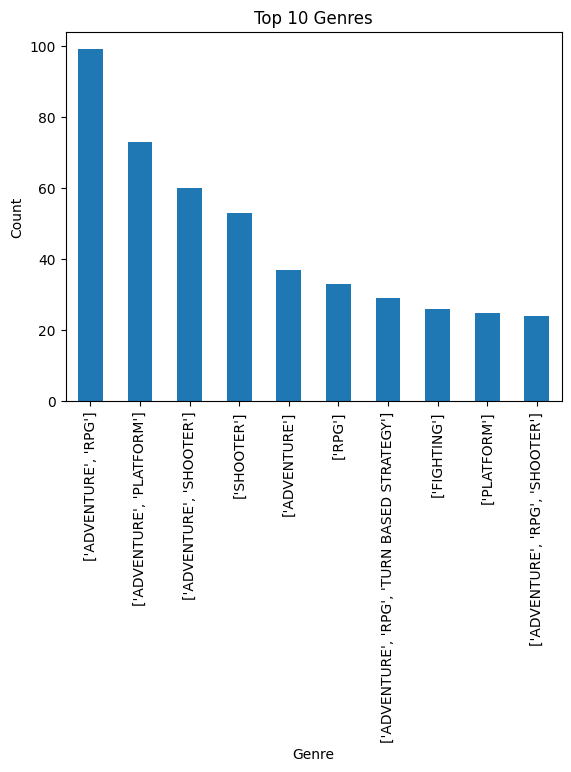

In [ ]:
games_copy['Genres'].value_counts().head(10).plot(kind='bar') # Bar chart of top 10 genres
plt.title('Top 10 Genres') # Set title
plt.xlabel('Genre') # Set X label
plt.ylabel('Count') # Set Y label
plt.show() # Display plot

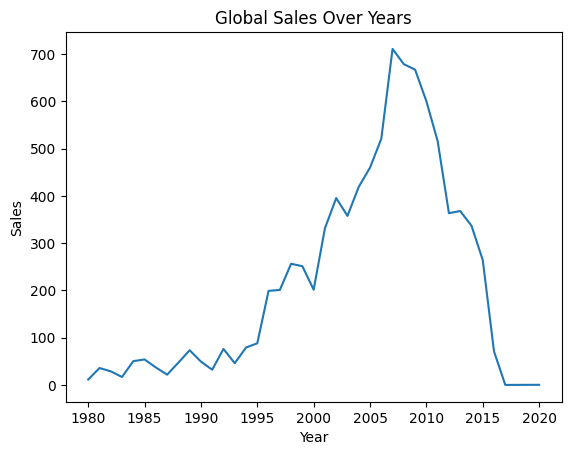

In [ ]:
sales_copy.groupby('Year')['Global_Sales'].sum().plot() # Line chart of global sales over years
plt.title('Global Sales Over Years') # Set title
plt.xlabel('Year') # Set X label
plt.ylabel('Sales') # Set Y label
plt.show() # Display plot

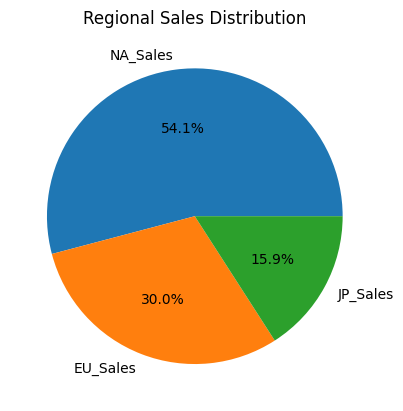

In [ ]:
sales_copy[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum().plot(kind='pie', autopct='%1.1f%%') # Pie chart of regional sales
plt.title('Regional Sales Distribution') # Set title
plt.ylabel('') # Remove y-axis label for pie chart
plt.show() # Display plot

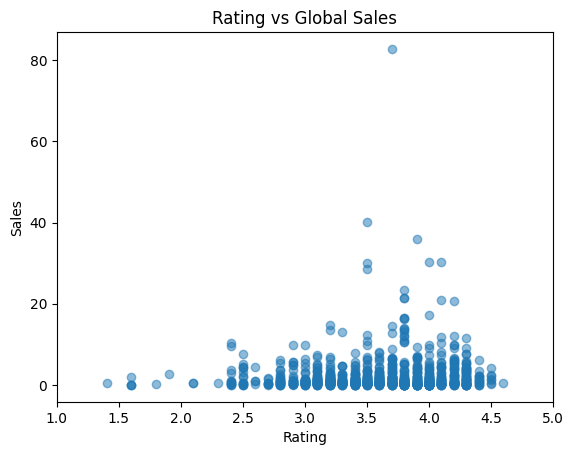

In [ ]:
merged = pd.merge(games_copy, sales_copy, left_on='Title', right_on='Name') # Merge games and sales
plt.scatter(merged['Rating'], merged['Global_Sales'],alpha=0.5) # Scatter plot: Rating vs Global Sales
plt.xlim(1, 5) # Set x-axis limit
plt.title('Rating vs Global Sales') # Set title
plt.xlabel('Rating') # Set X label
plt.ylabel('Sales') # Set Y label
plt.show() # Display plot

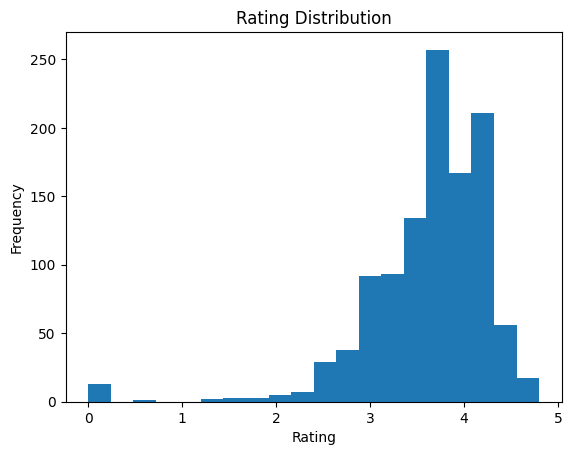

In [ ]:
games_copy['Rating'].plot(kind='hist', bins=20) # Histogram of Rating distribution
plt.title('Rating Distribution') # Set title
plt.xlabel('Rating') # Set X label
plt.show() # Display plot

In [ ]:
games_copy.to_csv('clean_games.csv', index=False) # Save cleaned games data
sales_copy.to_csv('clean_sales.csv', index=False) # Save cleaned sales data
merged.to_csv('merged_data.csv', index=False) # Save merged data

# Note: '/content/sample_data' refers to Colab's default directory.

In [ ]:
sales_copy # Display sales_copy
games_copy # Display games_copy

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,0,ELDEN RING,2022-02-25,"['BANDAI NAMCO ENTERTAINMENT', 'FROMSOFTWARE']",4.5,3.90,3.90,"['ADVENTURE', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17.00,3.80,4.60,4.80
1,1,HADES,2019-12-10,['SUPERGIANT GAMES'],4.3,2.90,2.90,"['ADVENTURE', 'BRAWLER', 'INDIE', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21.00,3.20,6.30,3.60
2,2,THE LEGEND OF ZELDA: BREATH OF THE WILD,2017-03-03,"['NINTENDO', 'NINTENDO EPD PRODUCTION GROUP NO...",4.4,4.30,4.30,"['ADVENTURE', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30.00,2.50,5.00,2.60
3,3,UNDERTALE,2015-09-15,"['TOBYFOX', '8-4']",4.2,3.50,3.50,"['ADVENTURE', 'INDIE', 'RPG', 'TURN BASED STRA...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28.00,0.68,4.90,1.80
4,4,HOLLOW KNIGHT,2017-02-24,['TEAM CHERRY'],4.4,3.00,3.00,"['ADVENTURE', 'INDIE', 'PLATFORM']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21.00,2.40,8.30,2.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507,1507,BACK TO THE FUTURE: THE GAME,2010-12-22,['TELLTALE GAMES'],3.2,0.09,0.09,"['ADVENTURE', 'POINT-AND-CLICK']",Back to the Future: The Game is one of Telltal...,['Very enjoyable game. The story adds onto the...,0.76,0.01,0.22,0.07
1508,1508,TEAM SONIC RACING,2019-05-21,"['SUMO DIGITAL', 'SEGA']",2.9,0.26,0.26,"['ARCADE', 'RACING']",Team Sonic Racing combines the best elements o...,"['jogo morto mas bom', 'not my cup of tea', ""C...",1.50,0.05,0.41,0.11
1509,1509,DRAGON'S DOGMA,2012-05-22,['CAPCOM'],3.7,0.21,0.21,"['BRAWLER', 'RPG']","Set in a huge open world, Dragon’s Dogma: Dark...","['Underrated.', 'A grandes rasgos, es como un ...",1.10,0.04,0.49,0.21
1510,1510,BALDUR'S GATE 3,2020-10-06,['LARIAN STUDIOS'],4.1,0.17,0.17,"['ADVENTURE', 'RPG', 'STRATEGY', 'TACTICAL', '...","An ancient evil has returned to Baldur's Gate,...",['Bu türe bu oyunla girmeye çalışmak hataydı s...,0.27,0.08,0.39,0.60


In [ ]:
games_copy['Unnamed: 0'].value_counts() # Count unique values in 'Unnamed: 0'

,count
Unnamed: 0,
1511,1
0,1
1,1
2,1
3,1
...,...
12,1
11,1
10,1


In [ ]:
if 'Unnamed: 0' in games_copy.columns: # Check if 'Unnamed: 0' exists
    games_copy = games_copy.drop(columns=['Unnamed: 0']) # Drop 'Unnamed: 0'

games_copy.insert(0, 'index', range(1, 1 + len(games_copy))) # Add new 'index' column

display(games_copy.head()) # Display modified games_copy

,index,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,1,ELDEN RING,2022-02-25,"['BANDAI NAMCO ENTERTAINMENT', 'FROMSOFTWARE']",4.5,3.9,3.9,"['ADVENTURE', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17.0,3.80,4.6,4.8
1,2,HADES,2019-12-10,['SUPERGIANT GAMES'],4.3,2.9,2.9,"['ADVENTURE', 'BRAWLER', 'INDIE', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21.0,3.20,6.3,3.6
2,3,THE LEGEND OF ZELDA: BREATH OF THE WILD,2017-03-03,"['NINTENDO', 'NINTENDO EPD PRODUCTION GROUP NO...",4.4,4.3,4.3,"['ADVENTURE', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30.0,2.50,5.0,2.6
3,4,UNDERTALE,2015-09-15,"['TOBYFOX', '8-4']",4.2,3.5,3.5,"['ADVENTURE', 'INDIE', 'RPG', 'TURN BASED STRA...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28.0,0.68,4.9,1.8
4,5,HOLLOW KNIGHT,2017-02-24,['TEAM CHERRY'],4.4,3.0,3.0,"['ADVENTURE', 'INDIE', 'PLATFORM']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21.0,2.40,8.3,2.3


In [ ]:
games_copy.to_csv('clean_games.csv', index=False) # Save cleaned games_copy to CSV

In [ ]:
sales_copy # Display sales_copy DataFrame

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,WII SPORTS,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,SUPER MARIO BROS.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,MARIO KART WII,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,WII SPORTS RESORT,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,POKEMON RED/POKEMON BLUE,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,WOODY WOODPECKER IN CRAZY CASTLE 5,GBA,2002,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,MEN IN BLACK II: ALIEN ESCAPE,GC,2003,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE INTERNATIONAL BAJA 1000: THE OFFICIAL GAME,PS2,2008,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,KNOW HOW 2,DS,2010,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01
